In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples = 5000,      # no of rows
                            n_features = 10,      # no of columns
                            n_informative = 6,    # Features that actually contain signal to predict the target
                            n_redundant = 2,      # Features that are linear combinations of the informative features (noise)
                            n_classes = 2,        # Binary classification
                            weights = [0.7, 0.3], # Class imbalance (70% of class 0, 30% of class 1)
                            random_state = 42)     


In [9]:
from sklearn.model_selection import train_test_split

# First split: train (60%) and temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y # It preserves the class distribution across splits.
)

# Second split: validation (20%) and test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp # It preserves the class distribution across splits.
)

In [10]:
from sklearn.linear_model import LogisticRegression

# Train baseline model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (3000, 10)
Validation: (1000, 10)
Test: (1000, 10)


*threshold tuning must use the validation set, keeping the test set untouched for the final unbiased evaluation.*

In [15]:
y_pred_val = model.predict(X_val)

y_proba_val = model.predict_proba(X_val)[:, 1]

print("Prediction Sample : ", y_pred_val[:10])
print("Probability Sample : ", y_proba_val[:10])
print("Total validation predictions : ", len(y_pred_val))

Prediction Sample :  [0 0 1 0 0 0 0 0 0 0]
Probability Sample :  [0.05289329 0.26124964 0.82443906 0.17756739 0.25598322 0.29632812
 0.26481885 0.0713466  0.04749793 0.19200857]
Total validation predictions :  1000


* If probability ≥ 0.5 → predict class 1
* If probability < 0.5 → predict class 0

In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred_val)
print("Validation Accuracy: ", accuracy)

Validation Accuracy:  0.794


In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_val)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[629  69]
 [137 165]]


* TN = 629
* FP = 69
* FN = 137
* TP = 165

> false negatives (137) are much higher than false positives (69), meaning the model is missing many actual positives.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_val, y_pred_val)  # shows how well the model identifies negative cases (class 0)
recall = recall_score(y_val, y_pred_val)        # shows how well the model identifies positive cases (class 1)
f1 = f1_score(y_val, y_pred_val)                # shows imblance in the dataset

print("Precision: ", precision, "# precision = TP / (TP + FP")
print("Recall: ", recall, "#recall = TP / (TP + FN)")
print("F1 Score: ", f1, "# F1 Score = 2 * (Precision * Recall) / (Precision + Recall)")

Precision:  0.7051282051282052 # precision = TP / (TP + FP
Recall:  0.5463576158940397 #recall = TP / (TP + FN)
F1 Score:  0.6156716417910447 # F1 Score = 2 * (Precision * Recall) / (Precision + Recall)  and reflects imbalance.


AUC: 0.8659082715042031


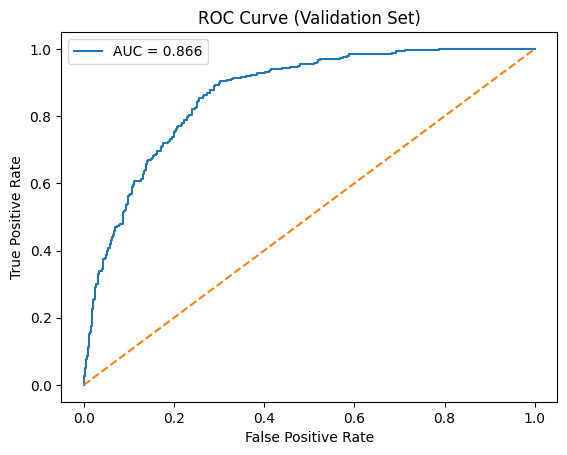

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_val, y_proba_val)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation Set)")
plt.legend()
plt.show()

*AUC ≈ 0.866, which indicates strong class separability; the ROC curve lies well above the diagonal, meaning the model performs substantially better than random guessing.*

In [23]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7] #The threshold is the cutoff value used to convert predicted probabilities into discrete class labels.

for t in thresholds:
    y_pred_thresh = (y_proba_val >= t).astype(int)
    precision = precision_score(y_val, y_pred_thresh)
    recall = recall_score(y_val, y_pred_thresh)
    f1 = f1_score(y_val, y_pred_thresh)
    print(f"Threshold: {t:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1 Score: {f1:.3f}")

Threshold: 0.20 | Precision: 0.532 | Recall: 0.914 | F1 Score: 0.672
Threshold: 0.30 | Precision: 0.601 | Recall: 0.798 | F1 Score: 0.686
Threshold: 0.40 | Precision: 0.658 | Recall: 0.682 | F1 Score: 0.670
Threshold: 0.50 | Precision: 0.705 | Recall: 0.546 | F1 Score: 0.616
Threshold: 0.60 | Precision: 0.756 | Recall: 0.421 | F1 Score: 0.540
Threshold: 0.70 | Precision: 0.809 | Recall: 0.308 | F1 Score: 0.446


*Lowering the threshold increases recall but reduces precision; raising it increases precision but drops recall. The highest F1 (~0.686) occurs near threshold = 0.30.*

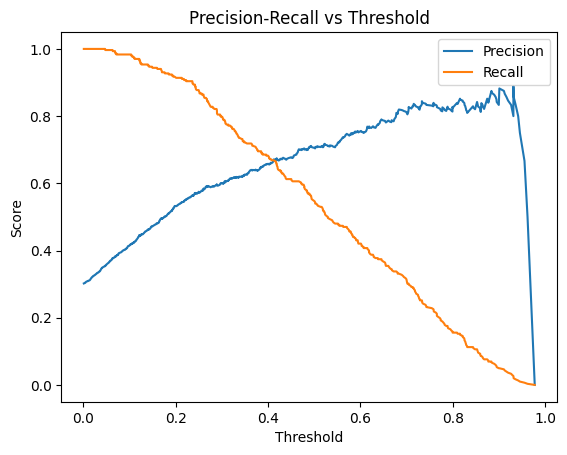

In [24]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba_val)

plt.figure()
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()


*In the 0.8–1.0 threshold region, the precision curve becomes unstable and eventually drops sharply because very few samples are predicted as positive.*

- Select a tuned threshold (e.g., 0.30, which maximized validation F1)

choosing the max F1 threshold means:

- precision and recall are most balanced
- neither false positives nor false negatives dominate

But this is only a default tuning strategy.

| Business Problem  | Metric Priority        |
| ----------------- | ---------------------- |
| Disease detection | maximize **recall**    |
| Spam filter       | maximize **precision** |
| Fraud detection   | often **recall-heavy** |
| Balanced tasks    | **F1**                 |


In [25]:
y_proba_test = model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred_test = (y_proba_test >= threshold).astype(int)

# metrics
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)

print("Threshold:", threshold)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)

Threshold: 0.3
Accuracy: 0.795
Precision: 0.6234096692111959
Recall: 0.8112582781456954
F1-score: 0.7050359712230215
Confusion Matrix:
 [[550 148]
 [ 57 245]]
